<a href="https://colab.research.google.com/github/Faisaleka21/Machine_Learning/blob/main/Evaluasi%20Model%20Klasifikasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score, precision_score,recall_score, f1_score, roc_auc_score
from sklearn.metrics import RocCurveDisplay

In [17]:
df =pd.read_csv("https://raw.githubusercontent.com/febbisena/DataMining/refs/heads/main/banana_quality.csv")
df

,Size,Weight,Sweetness,Softness,HarvestTime,Ripeness,Acidity,Quality
0,-1.924968,0.468078,3.077832,-1.472177,0.294799,2.435570,0.271290,Good
1,-2.409751,0.486870,0.346921,-2.495099,-0.892213,2.067549,0.307325,Good
2,-0.357607,1.483176,1.568452,-2.645145,-0.647267,3.090643,1.427322,Good
3,-0.868524,1.566201,1.889605,-1.273761,-1.006278,1.873001,0.477862,Good
4,0.651825,1.319199,-0.022459,-1.209709,-1.430692,1.078345,2.812442,Good
...,...,...,...,...,...,...,...,...
7995,-6.414403,0.723565,1.134953,2.952763,0.297928,-0.156946,2.398091,Bad
7996,0.851143,-2.217875,-2.812175,0.489249,-1.323410,-2.316883,2.113136,Bad
7997,1.422722,-1.907665,-2.532364,0.964976,-0.562375,-1.834765,0.697361,Bad
7998,-2.131904,-2.742600,-1.008029,2.126946,-0.802632,-3.580266,0.423569,Bad


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Size         8000 non-null   float64
 1   Weight       8000 non-null   float64
 2   Sweetness    8000 non-null   float64
 3   Softness     8000 non-null   float64
 4   HarvestTime  8000 non-null   float64
 5   Ripeness     8000 non-null   float64
 6   Acidity      8000 non-null   float64
 7   Quality      8000 non-null   object 
dtypes: float64(7), object(1)
memory usage: 500.1+ KB


In [19]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [20]:
print(y.value_counts())

Quality
Good    4006
Bad     3994
Name: count, dtype: int64


In [21]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

y_encoded

array([1, 1, 1, ..., 0, 0, 0])

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,
y_encoded, test_size=0.2, random_state=42)

print("Data train : ", len(X_train))
print("Data test : ", len(X_test))

Data train :  6400
Data test :  1600


In [23]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [24]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

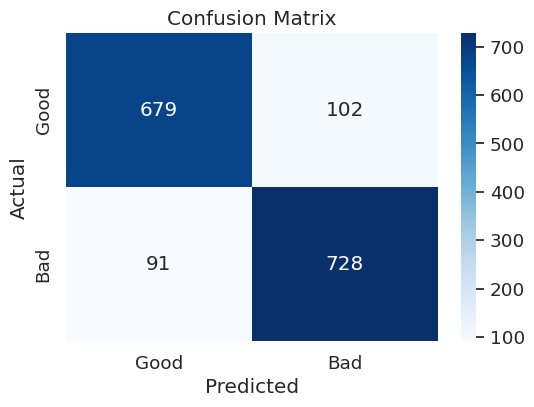

In [25]:
# EVALUASI MODEL KLASIFIKASI
# CONFUSION MATRIX

class_names = y.unique()

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))

sns.set(font_scale=1.2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [26]:
# CLASSIFICATION REPORT

class_report = classification_report(y_test, y_pred,
target_names=class_names, digits=4)
print("Classification Report :\n", class_report)

Classification Report :
               precision    recall  f1-score   support

        Good     0.8818    0.8694    0.8756       781
         Bad     0.8771    0.8889    0.8830       819

    accuracy                         0.8794      1600
   macro avg     0.8795    0.8791    0.8793      1600
weighted avg     0.8794    0.8794    0.8793      1600



In [27]:
# AKURASI

acc = accuracy_score(y_test, y_pred) * 100
print(f"Accuracy : {acc:.2f}%")

Accuracy : 87.94%


In [28]:
# PRESISI

prec = precision_score(y_test, y_pred, average='macro') *100
print(f"Precision : {prec:.2f}%")

Precision : 87.95%


In [29]:
# RECALL

rec = recall_score(y_test, y_pred, average='macro') * 100
print(f"Recall : {rec:.2f}%")

Recall : 87.91%


In [30]:
# F1-SCORE

f1 = f1_score(y_test, y_pred, average='macro') * 100
print(f"F1 Score : {f1:.2f}%")

F1 Score : 87.93%


In [31]:
# ROC-AUC

roc_auc = roc_auc_score(y_test, y_proba) * 100
print(f"ROC AUC : {roc_auc:.2f}%")

ROC AUC : 94.89%


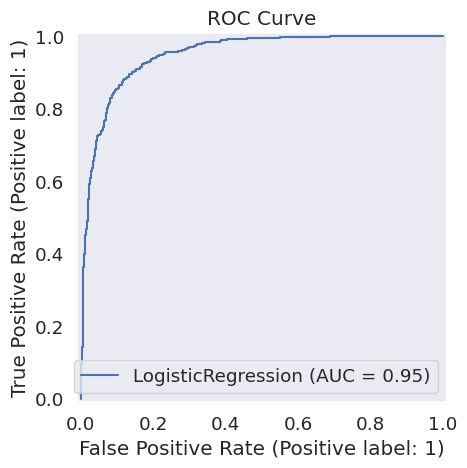

In [32]:
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.grid()
plt.show()